<a href="https://colab.research.google.com/github/neysazefanya/Latihan-Passing-Data-dan-Git/blob/main/neysa_probstat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
# =========================================================
# A. PENGORGANISASIAN DATA
# =========================================================

# 1. Import Data Excel
dataraw = pd.read_excel("neysa.xlsx")

# 2. Styling
th_style = "background-color: #ff4d8d; color: white; font-weight: bold; text-align: center; padding: 6px 12px;"
td_style = "text-align: center; padding: 6px 12px; border: 1px solid #ff85a1;"

print("=== DATA MENTAH ===")
styled_dataraw = dataraw.style.set_table_styles([
    {"selector": "th", "props": th_style},
    {"selector": "td", "props": td_style},
    {"selector": "tr:nth-child(even)", "props": "background-color: #fffae6;"},
    {"selector": "tr:nth-child(odd)", "props": "background-color: #fff0f5;"},

styled_dataraw

_IncompleteInputError: incomplete input (3327061544.py, line 19)

In [14]:
# Load & Buat Tabel Frekuensi
dataraw = pd.read_excel("neysa.xlsx")
grade_order = ["A", "AB", "B", "BC", "C", "F"]

datafrq = dataraw["Grade"].value_counts().reindex(grade_order, fill_value=0).to_frame("Frekuensi")
datafrq["Persentase (%)"] = (datafrq["Frekuensi"] / datafrq["Frekuensi"].sum() * 100).round(1)

# 2. Styling Tabel
th_style = "background-color: #ff4d8d; color: white; font-weight: bold; text-align: center; padding: 8px;"
td_style = "text-align: center; padding: 8px; border: 1px solid #ff85a1;"

styled_table = datafrq.style.set_table_styles([
    {"selector": "th", "props": th_style},
    {"selector": "td", "props": td_style},
    {"selector": "tr:nth-child(even)", "props": "background-color: #fffae6;"},
    {"selector": "tr:nth-child(odd)", "props": "background-color: #fff0f5;"},
]).format({"Persentase (%)": "{:.1f}%"})

styled_table

,Frekuensi,Persentase (%)
Grade,,
A,13,41.9%
AB,7,22.6%
B,4,12.9%
BC,1,3.2%
C,5,16.1%
F,1,3.2%


In [16]:
# =========================================================
# C. STATISTIKA DESKRIPTIF
# =========================================================

# 1. Hitung Statistika Deskriptif
dt = pd.to_numeric(dataraw["Nilai"], errors="coerce")

stats_dict = {
    **dt.describe().to_dict(),
    "Standard Error": dt.sem(),
    "Median": dt.median(),
    "Mode": dt.mode().iloc[0],
    "Variance": dt.var(),
    "Range": dt.max() - dt.min(),
    "Skewness": dt.skew(),
    "Kurtosis": dt.kurtosis(),
}

df_stats = pd.DataFrame(
    list(stats_dict.items()), columns=["Ukuran Statistik", "Nilai"]
)

# 2. Styling
th_style = "background-color: #ff4d8d; color: white; font-weight: bold; text-align: center; padding: 8px 16px;"
td_style = "text-align: center; padding: 8px 16px; border: 1px solid #ff85a1;"

print("=== STATISTIKA DESKRIPTIF ===")
styled_stats = (
    df_stats.style.set_table_styles([
        {"selector": "th", "props": th_style},
        {"selector": "td", "props": td_style},
        {"selector": "tr:nth-child(even)", "props": "background-color: #fffae6;"},
        {"selector": "tr:nth-child(odd)", "props": "background-color: #fff0f5;"},
    ])
    .format({"Nilai": "{:.2f}"})
)

styled_stats

=== STATISTIKA DESKRIPTIF ===


,Ukuran Statistik,Nilai
0,count,31.00
1,mean,76.79
2,std,13.61
3,min,46.01
4,25%,68.80
5,50%,79.30
6,75%,87.47
7,max,94.03
8,Standard Error,2.44
9,Median,79.30


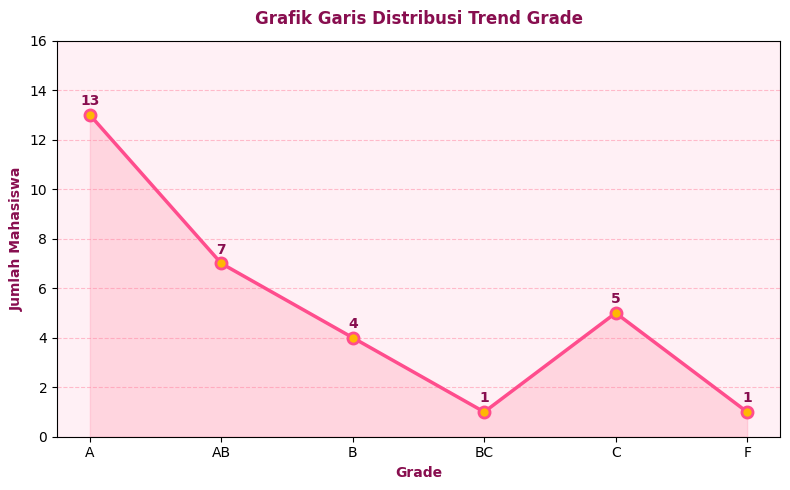

In [17]:
# =========================================================
# B. PENYAJIAN DATA
# =========================================================

# 1. GRAFIK GARIS
plt.figure(figsize=(8, 5))

# 1. Plot Garis & Fill Area
plt.plot(
    datafrq.index,
    datafrq["Frekuensi"],
    marker="o",
    lw=2.5,
    ms=8,
    color="#ff4d8d",
    mfc="#ffb703",
    mew=2,
    mec="#ff4d8d",
)
plt.fill_between(datafrq.index, datafrq["Frekuensi"], color="#ff85a1", alpha=0.25)

# 2. Styling Background & Grid
plt.gca().set_facecolor("#fff0f5")
plt.grid(axis="y", ls="--", alpha=0.5, color="#ff85a1")

# 3. Judul & Label Sumbu
style = {"fontsize": 10, "fontweight": "bold", "color": "#880e4f"}
plt.title("Grafik Garis Distribusi Trend Grade", pad=12, **{**style, "fontsize": 12})
plt.xlabel("Grade", **style)
plt.ylabel("Jumlah Mahasiswa", **style)

# 4. Annotate Teks di Atas Titik
for x, y in zip(datafrq.index, datafrq["Frekuensi"]):
    plt.annotate(f"{int(y)}", (x, y + 0.4), ha="center", fontweight="bold", color="#880e4f")

plt.ylim(0, max(datafrq["Frekuensi"]) + 3)
plt.tight_layout()
plt.show()

In [ ]:
# 2. GRAFIK BATANG (BAR CHART) ---
plt.figure(figsize=(8, 5))

# 1. Plot Bar Chart
bars = plt.bar(
    datafrq.index,
    datafrq["Frekuensi"],
    color=custom_colors,
    edgecolor="#880e4f",
    linewidth=1.2,
    alpha=0.9,
)

# 2. Tambahkan Data Label
plt.bar_label(bars, fmt="%d", padding=3, fontweight="bold", color="#880e4f")

# 3. Styling Background & Grid
plt.gca().set_facecolor("#fff0f5")
plt.grid(axis="y", ls="--", alpha=0.5, color="#ff85a1")

# 4. Style Reusable & Teks
lbl_style = {"fontsize": 10, "fontweight": "bold", "color": "#880e4f"}

plt.title("Grafik Batang Frekuensi Mahasiswa per Grade", pad=12, fontsize=12, fontweight="bold", color="#880e4f")
plt.xlabel("Grade", **lbl_style)
plt.ylabel("Jumlah Mahasiswa", **lbl_style)

plt.ylim(0, max(datafrq["Frekuensi"]) + 3)
plt.tight_layout()
plt.show()

In [ ]:
# 3. GRAFIK PIE / DONUT (DONUT CHART) ---
plt.figure(figsize=(7, 5))

# 1. Gambar Donut Chart
wedges, texts, autotexts = plt.pie(
    datafrq["Frekuensi"],
    labels=datafrq.index,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=custom_colors,
    startangle=140,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2},
)

# 2. Styling
plt.setp(texts, color="#880e4f", weight="bold", fontsize=11)
plt.setp(autotexts, color="#4a0e17", weight="bold", fontsize=9.5)

# 3. Judul & Layout
plt.title(
    "Grafik Pie / Donut Proporsi Grade Mahasiswa",
    fontsize=12,
    fontweight="bold",
    pad=12,
    color="#880e4f",
)
plt.tight_layout()
plt.show()